Ce projet porte sur l’enregistrement de l’activité cérébrale chez un patient sain et un patient en crise épileptique.

L’objectif de ce projet est:
1. Est-ce qu'on peut voir une différence entre un signal EEG normal et un signal épileptique ?
2. Est-ce que les deux signaux ont le même contenu fréquentiel ?
3. Est-ce que la puissance du signal permet de les distinguer ?

Import des bibliothèques

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [37]:
data = pd.read_csv("Epileptic Seizure Recognition.csv")

D'après le dataset, on obtient comme informations:  11500 enregsitrements EEG et 180 points 

In [38]:
data.shape

(11500, 180)

Le dataset contient 11 500 enregistrements EEG. Chaque ligne correspond à 1 seconde d'activité cérébrale enregistrée à 180 Hz.

In [42]:
data.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [43]:
data["y"].value_counts()

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

Séparation des deux groupes

In [44]:
data_normal  = data[data["y"] == 5].reset_index(drop=True)
data_seizure = data[data["y"] == 1].reset_index(drop=True)

In [45]:
print("Signaux normaux :", len(data_normal))
print("Signaux épileptiques :", len(data_seizure))

Signaux normaux : 2300
Signaux épileptiques : 2300


Extraction d'un signal normal et d'un signal épileptique

In [46]:
signal_normal  = data_normal.iloc[0, 1:-1].values
signal_seizure = data_seizure.iloc[0, 1:-1].values

In [47]:
fs   = 180
time = np.linspace(0, 1, len(signal_normal))

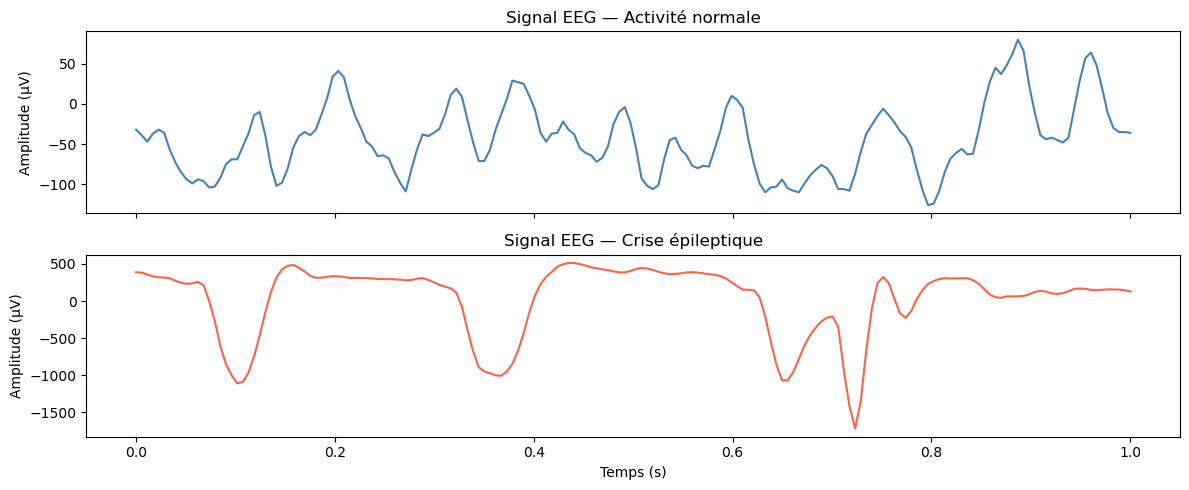

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(time, signal_normal, color="steelblue")
axes[0].set_title("Signal EEG — Activité normale")
axes[0].set_ylabel("Amplitude (µV)")

axes[1].plot(time, signal_seizure, color="tomato")
axes[1].set_title("Signal EEG — Crise épileptique")
axes[1].set_ylabel("Amplitude (µV)")
axes[1].set_xlabel("Temps (s)")

plt.tight_layout()
plt.show()

In [66]:
n     = len(signal_normal)
freqs = np.fft.rfftfreq(n, d=1/fs)

In [56]:
nyq  = fs / 2
b, a = butter(4, [0.5 / nyq, 40 / nyq], btype="band")

In [67]:
signal_normal_filtre  = filtfilt(b, a, signal_normal)
signal_seizure_filtre = filtfilt(b, a, signal_seizure)

J'ai appliqué un filtre passe-bande afin de nettoyer le signal EEG en éliminant les fréquences parasites qui ne correspondent pas à une activité cérébrale.
Sur le graphique, on observe que le signal filtré est plus propre que le signal brut, tout en conservant ses caractéristiques principales. Les fréquences en dessous de 0.5 Hz correspondaient à des artefacts de mouvement ou de transpiration, et les fréquences au dessus de 40 Hz à du bruit électrique et des artefacts musculaires.

On peut en déduire que l'activité neuronale est masquée par ces bruits lorsqu'on travaille sur un signal brut. Le filtrage permet d'isoler les fréquences entre 0.5 et 40 Hz, qui correspondent aux rythmes cérébraux d'intérêt, ce qui améliore la qualité du signal.
Ces résultats montrent que le filtrage du signal EEG est une étape essentielle avant toute analyse. Cela montre que ce type de prétraitement peut être utile pour obtenir des données plus fiables et mieux détecter les anomalies cérébrales.

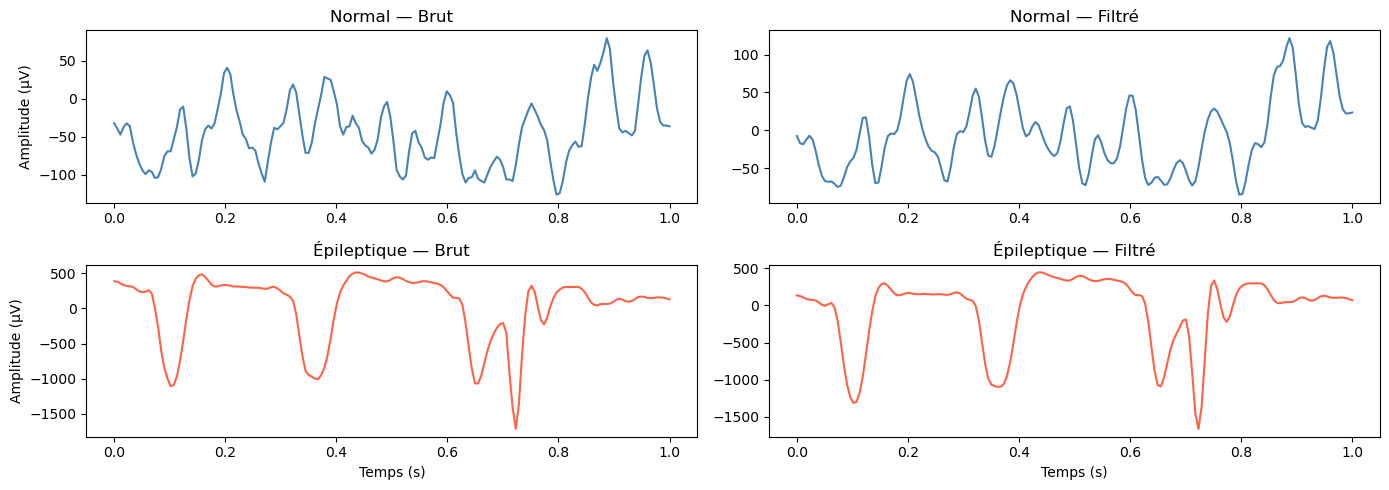

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 5))

axes[0, 0].plot(time, signal_normal, color="steelblue")
axes[0, 0].set_title("Normal — Brut")
axes[0, 0].set_ylabel("Amplitude (µV)")

axes[0, 1].plot(time, signal_normal_filtre, color="steelblue")
axes[0, 1].set_title("Normal — Filtré")

axes[1, 0].plot(time, signal_seizure, color="tomato")
axes[1, 0].set_title("Épileptique — Brut")
axes[1, 0].set_ylabel("Amplitude (µV)")
axes[1, 0].set_xlabel("Temps (s)")

axes[1, 1].plot(time, signal_seizure_filtre, color="tomato")
axes[1, 1].set_title("Épileptique — Filtré")
axes[1, 1].set_xlabel("Temps (s)")

plt.tight_layout()
plt.show()

Un signal EEG brut contient du bruit qui ne vient pas du cerveau. En dessous de 0.5 Hz, on trouve des artefacts de mouvement ou de transpiration. Au dessus de 40 Hz, du bruit électrique et des artefacts musculaires. J'ai appliqué un filtre passe-bande pour ne garder que les fréquences entre 0.5 et 40 Hz, qui correspondent aux rythmes cérébraux d'intérêt. On voit que le signal filtré est plus propre tout en conservant ses caractéristiques principales. C'est le prétraitement de base en EEG clinique avant toute analyse. simplifie ce paragraphe

Sur le graphique, on observe que le signal filtré est plus propre que le signal brut, tout en conservant ses caractéristiques principales. Les fréquences en dessous de 0.5 Hz correspondaient à des artefacts de mouvement ou de transpiration, et les fréquences au dessus de 40 Hz à du bruit électrique et des artefacts musculaires.

On peut en déduire que l'activité neuronale est masquée par ces bruits lorsqu'on travaille sur un signal brut. Le filtrage permet d'isoler les fréquences entre 0.5 et 40 Hz, qui correspondent aux rythmes cérébraux d'intérêt, ce qui améliore la qualité du signal.

Ces résultats montrent que le filtrage du signal EEG est une étape essentielle avant toute analyse. Cela montre que ce type de prétraitement peut être utile pour obtenir des données plus fiables et mieux détecter les anomalies cérébrales.Calcul de la puissance de chaque signal

In [59]:
normal_powers  = []
seizure_powers = []

for i in range(len(data_normal)):
    signal = data_normal.iloc[i, 1:-1].values
    normal_powers.append(np.mean(signal**2))

for i in range(len(data_seizure)):
    signal = data_seizure.iloc[i, 1:-1].values
    seizure_powers.append(np.mean(signal**2))

In [60]:
print("Puissance moyenne — Normal      :", round(np.mean(normal_powers), 1))
print("Puissance moyenne — Épileptique :", round(np.mean(seizure_powers), 1))

Puissance moyenne — Normal      : 2375.3
Puissance moyenne — Épileptique : 116406.4


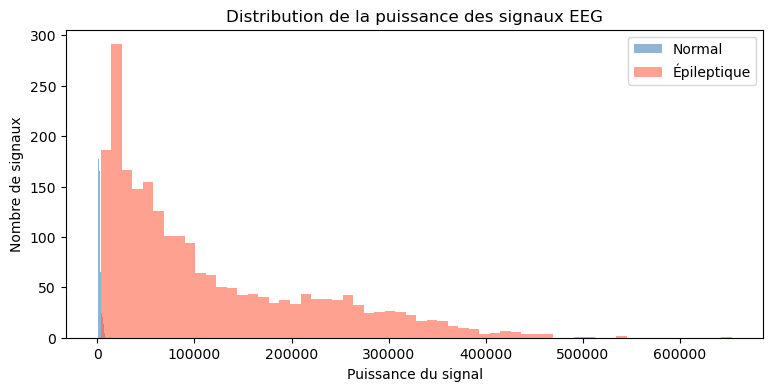

In [61]:
plt.figure(figsize=(9, 4))
plt.hist(normal_powers,  bins=60, alpha=0.6, color="steelblue", label="Normal")
plt.hist(seizure_powers, bins=60, alpha=0.6, color="tomato",    label="Épileptique")
plt.xlabel("Puissance du signal")
plt.ylabel("Nombre de signaux")
plt.title("Distribution de la puissance des signaux EEG")
plt.legend()
plt.show()

Les signaux EEG reflètent l'activité électrique des neurones du cerveau. Cette activité est liée aux variations du potentiel de membrane, qui permettent aux neurones de transmettre des informations sous forme de signaux électriques. J'ai calculé la puissance des signaux EEG afin de mesurer l'intensité de cette activité électrique.

Sur le graphique, on observe que la distribution de la puissance des signaux n'est pas la même pour les signaux normaux et les signaux associés aux crises épileptiques. Les signaux épileptiques atteignent des valeurs beaucoup plus élevées, tandis que les signaux normaux sont concentrés dans une zone plus restreinte avec une puissance faible.

On peut en déduire que l'activité neuronale est différente selon l'état du cerveau. Pendant une crise épileptique, les neurones se dépolarisent simultanément et de façon anormalement synchronisée, ce qui génère des signaux d'amplitude très élevée et donc de puissance plus importante.

Ces résultats montrent que l'analyse de la puissance des signaux EEG permet de mettre en évidence des différences entre une activité cérébrale normale et une activité pathologique. Cela montre que ce type d'analyse peut être utile pour mieux comprendre le fonctionnement du cerveau et détecter certaines anomalies.